In [1]:
#%%
import numpy as np  # the numpy module is associated with the alias np
import cv2          # OpenCV module
import matplotlib
import matplotlib.pyplot as plt    # the matplotlib.pyplot with the alias plt
from IPython.display import Image, display, clear_output  # Shows an image in the notebook
import time                        # module to mesuare time cost
from skimage.data import page
from skimage.filters import (threshold_otsu, threshold_niblack, threshold_sauvola)

In [2]:
#%%
print('Numpy:',np.__version__)
print('OpenCv:',cv2.__version__)

Numpy: 2.2.2
OpenCv: 4.11.0


In [3]:
# %%
#Pre-Processing
#Load the Image
beans_img = cv2.imread('000007.bmp')
beans_img = cv2.cvtColor(beans_img, cv2.COLOR_BGR2RGB)

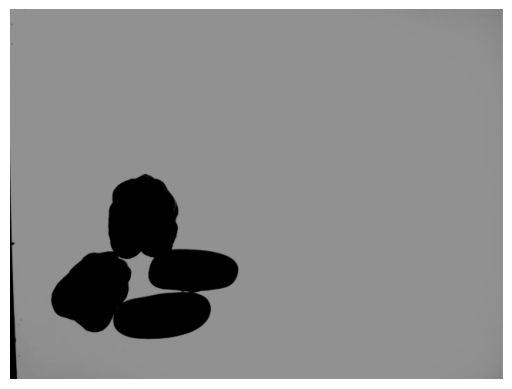

In [4]:
# Display using Matplotlib
plt.imshow(beans_img)
plt.axis('off')  # Hide axes
plt.show()

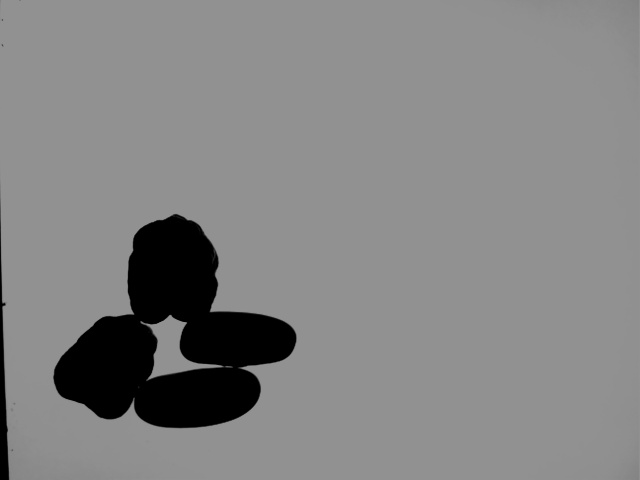

In [12]:
# %%
img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)
# %%
# Shows the processed image
Image(cv2.imencode('.jpg', img_gray)[1])

C:\Users\decap\AppData\Local\Temp\ipykernel_6128\227334334.py:3: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_gray.ravel(),256,[0,256], color = "gray")


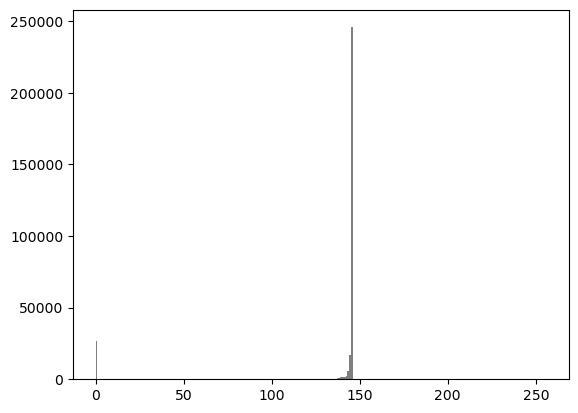

In [6]:
# %%
#Shows the histogram
plt.hist(img_gray.ravel(),256,[0,256], color = "gray")
plt.show()

In [11]:
#%%
height, width = img_gray.shape

border_x = int(height * 0.02)  
border_y = int(width * 0.02)  

In [8]:
# Berechne neue Begrenzungen
x_ini = border_x
x_end = height - border_x
y_ini = border_y
y_end = width - border_y

In [9]:
# Ausschneiden des zentralen Bereichs ohne Ränder
img_cropped = img_gray[x_ini:x_end, y_ini:y_end]
print('Cropped region of interest:', x_ini, x_end, y_ini, y_end)
img_resized = img_gray[x_ini:x_end, y_ini:y_end]

Cropped region of interest: 9 471 12 628


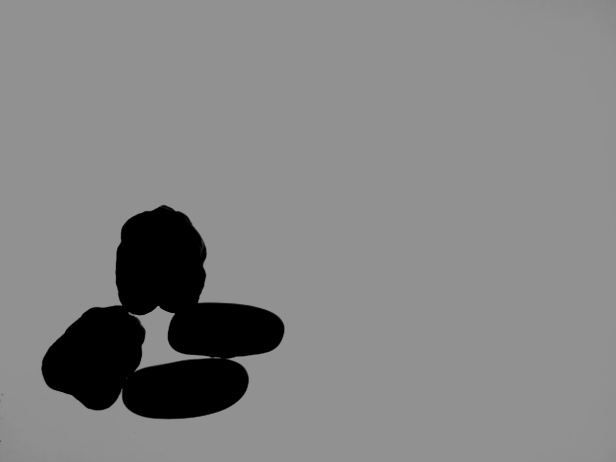

In [10]:
# Shows cropped image
Image(cv2.imencode('.jpg', img_resized)[1])

--- 0.00037288665771484375 seconds ---


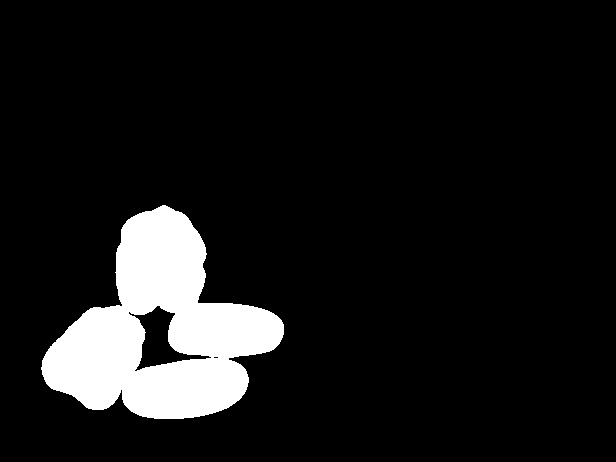

In [54]:
# %%
# Fixed threshold method
start_time = time.time()
threshold = 75
ret, img_segmented = cv2.threshold(img_resized, threshold, 255, cv2.THRESH_BINARY_INV)
print("--- %s seconds ---" % (time.time() - start_time))

# Shows segmented image
Image(cv2.imencode('.jpg', img_segmented)[1])

--- 0.00036072731018066406 seconds ---


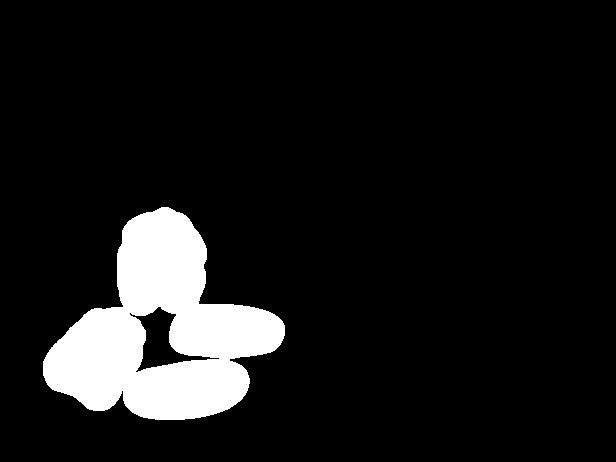

In [55]:
# %%
# Application of the open transformation with a (6.6) pixel kernel 
start_time = time.time()
kernel = np.ones((6,6),np.uint8)
img_opened = cv2.morphologyEx(img_segmented, cv2.MORPH_OPEN, kernel)
print("--- %s seconds ---" % (time.time() - start_time))

# Mostrar la imagen procesada
Image(cv2.imencode('.jpg', img_opened)[1])

--- 0.00034356117248535156 seconds ---


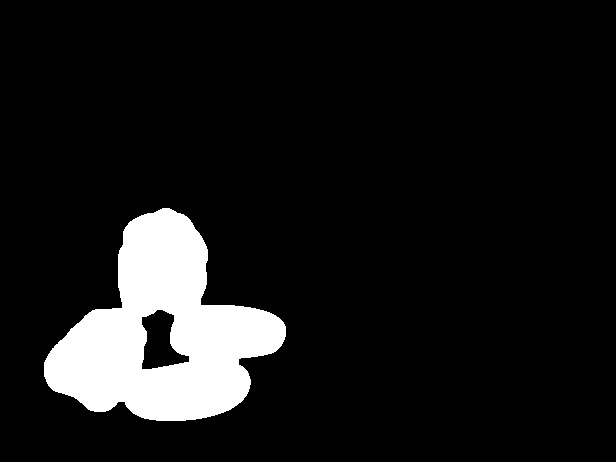

In [56]:
# %%
# Application of the close transformation with a (6.6) pixel kernel 
start_time = time.time()
kernel = np.ones((6,6),np.uint8)
img_opened_closed = cv2.morphologyEx(img_opened, cv2.MORPH_CLOSE, kernel)
print("--- %s seconds ---" % (time.time() - start_time))

# Mostrar la imagen procesada
Image(cv2.imencode('.jpg', img_opened_closed)[1])

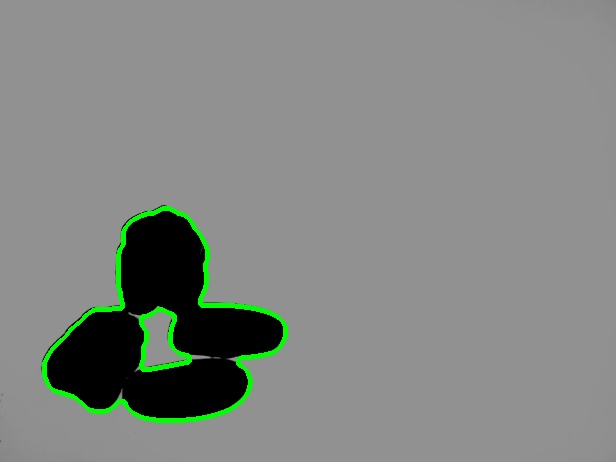

In [57]:
# In OpenCv, the labeling algorithm is called findContours
contours, hierarchy = cv2.findContours(img_opened_closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# All the contours of the objects of interest are drawn in green with a thickness of 3
img_contours =beans_img.copy()
img_contours = beans_img.copy()
img_cropped_contours = img_contours[x_ini:x_end, y_ini:y_end]

cv2.drawContours(img_cropped_contours, contours, -1, (0,255,0), 3)

# Shows image with contours
Image(cv2.imencode('.jpg', img_cropped_contours)[1])

In [58]:
# %%
start_time = time.time()
for cnt in contours:
    
    #display_handle=display(None, display_id=True)
    # Copy the original image
    img_contours = beans_img.copy()
    img_cropped_contours = img_contours[x_ini:x_end, y_ini:y_end]

    # Draws each contour
    cv2.drawContours(img_cropped_contours, [cnt], 0, (0,255,0), 3)

    # Shows each contour
    #display_handle.update(Image(cv2.imencode('.jpg', img_contours)[1]))
    
    #input('Press enter to continue...')
    #clear_output()

    #display_handle.update(None)

print('Number of Elements:', len(contours))
print("--- %s seconds ---" % (time.time() - start_time))

Number of Elements: 2
--- 0.0008013248443603516 seconds ---


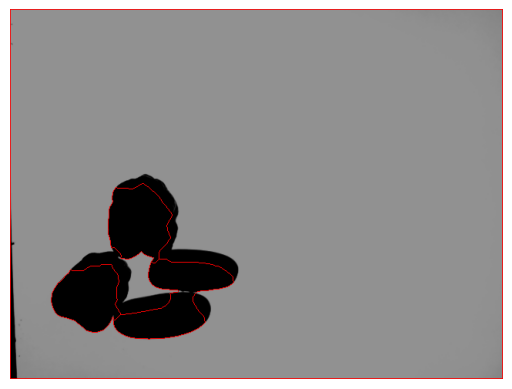

In [63]:
# Convertiamo l'immagine a RGB se non lo è già
beans_img_marked = beans_img.copy()

# Assicuriamoci che markers abbia le stesse dimensioni di beans_img
markers_resized = cv2.resize(markers, (beans_img.shape[1], beans_img.shape[0]), interpolation=cv2.INTER_NEAREST)

# Applichiamo il Watershed
cv2.watershed(beans_img_marked, markers_resized)

# Disegniamo i bordi in rosso
beans_img_marked[markers_resized == -1] = [255, 0, 0]

# Mostra il risultato
plt.imshow(beans_img_marked)
plt.axis('off')
plt.show()


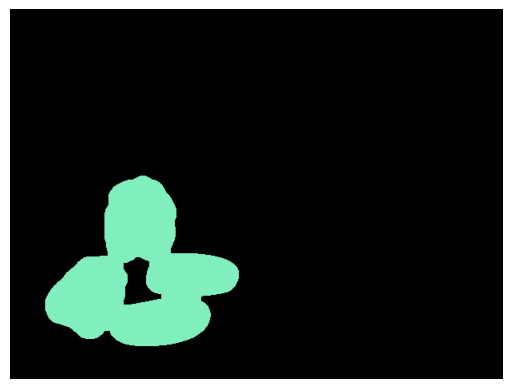

Numero di oggetti rilevati: 1


In [64]:
# Connected Component Labeling
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img_opened_closed, connectivity=8)

# Creiamo un'immagine vuota con le stesse dimensioni di labels e con 3 canali per i colori
img_ccl = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)

# Coloriamo ogni oggetto con un colore casuale
for i in range(1, num_labels):  # Ignoriamo il background
    mask = labels == i
    color = np.random.randint(0, 255, size=(3,), dtype=np.uint8)  # Colore casuale per ogni oggetto
    img_ccl[mask] = color  # Applichiamo il colore ai pixel corrispondenti

# Mostriamo l'immagine etichettata
plt.imshow(img_ccl)
plt.axis('off')
plt.show()

print(f'Numero di oggetti rilevati: {num_labels - 1}')  # Escludiamo il background
